# Proyecto Final: Clasificación de Textos por Década (v3)

Versión enfocada en la siguiente tanda de envíos a Kaggle.

Cambios clave frente a la v2:
- prioriza **n-gramas de caracteres puros** (`analyzer="char"`) además de mantener algunos controles con `char_wb`;
- elimina del flujo principal el `exact-match override`, porque ya no movió el score en Kaggle;
- arma un **pack de 5 submissions** realmente distintos: 4 modelos individuales + 1 ensamble ponderado;
- mantiene la estructura del proyecto: guarda el modelo en `models/` y los CSV en `data/submissions/`.


## 1. Importación de librerías

In [ ]:
from pathlib import Path
import inspect
import re
import time
from collections import defaultdict

import joblib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC


## 2. Configuración de ejecución

`RUN_FULL_MODEL_COMPARISON=True` prueba todo el menú.
`RUN_FIVE_SUBMISSIONS=True` genera el pack de envíos para Kaggle.


In [12]:
RUN_FULL_MODEL_COMPARISON = True
RUN_FIVE_SUBMISSIONS = True
TOP_MODELS_FOR_SUBMISSIONS = 4
INCLUDE_ENSEMBLE_SUBMISSION = False

# Límites de features para controlar memoria/tiempo
WORD_MAX_FEATURES = 160_000
CHAR_PLAIN_15_MAX_FEATURES = 380_000
CHAR_PLAIN_25_MAX_FEATURES = 420_000
CHAR_PLAIN_26_MAX_FEATURES = 500_000
CHAR_WB_35_MAX_FEATURES = 260_000
CHAR_WB_36_MAX_FEATURES = 320_000
WORD_CHAR_WORD_MAX_FEATURES = 120_000
WORD_CHAR_CHAR_MAX_FEATURES = 220_000

config_df = pd.DataFrame(
    {
        "parameter": [
            "RUN_FULL_MODEL_COMPARISON",
            "RUN_FIVE_SUBMISSIONS",
            "TOP_MODELS_FOR_SUBMISSIONS",
            "INCLUDE_ENSEMBLE_SUBMISSION",
            "WORD_MAX_FEATURES",
            "CHAR_PLAIN_15_MAX_FEATURES",
            "CHAR_PLAIN_25_MAX_FEATURES",
            "CHAR_PLAIN_26_MAX_FEATURES",
            "CHAR_WB_35_MAX_FEATURES",
            "CHAR_WB_36_MAX_FEATURES",
            "WORD_CHAR_WORD_MAX_FEATURES",
            "WORD_CHAR_CHAR_MAX_FEATURES",
        ],
        "value": [
            RUN_FULL_MODEL_COMPARISON,
            RUN_FIVE_SUBMISSIONS,
            TOP_MODELS_FOR_SUBMISSIONS,
            INCLUDE_ENSEMBLE_SUBMISSION,
            WORD_MAX_FEATURES,
            CHAR_PLAIN_15_MAX_FEATURES,
            CHAR_PLAIN_25_MAX_FEATURES,
            CHAR_PLAIN_26_MAX_FEATURES,
            CHAR_WB_35_MAX_FEATURES,
            CHAR_WB_36_MAX_FEATURES,
            WORD_CHAR_WORD_MAX_FEATURES,
            WORD_CHAR_CHAR_MAX_FEATURES,
        ],
    }
)
display(config_df)


,parameter,value
0,RUN_FULL_MODEL_COMPARISON,True
1,RUN_FIVE_SUBMISSIONS,True
2,TOP_MODELS_FOR_SUBMISSIONS,4
3,INCLUDE_ENSEMBLE_SUBMISSION,False
4,WORD_MAX_FEATURES,160000
5,CHAR_PLAIN_15_MAX_FEATURES,380000
6,CHAR_PLAIN_25_MAX_FEATURES,420000
7,CHAR_PLAIN_26_MAX_FEATURES,500000
8,CHAR_WB_35_MAX_FEATURES,260000
9,CHAR_WB_36_MAX_FEATURES,320000


## 3. Carga de datos y estructura del proyecto

El notebook intenta correr bien desde `notebooks/`, desde la raíz del proyecto o desde un entorno tipo ChatGPT/Kaggle.


In [13]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
SUBMISSIONS_DIR = PROJECT_ROOT / "data" / "submissions"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

train_candidates = [
    PROJECT_ROOT / "data" / "train.csv",
    PROJECT_ROOT / "train.csv",
    Path("/mnt/data/train.csv"),
]
eval_candidates = [
    PROJECT_ROOT / "data" / "eval.csv",
    PROJECT_ROOT / "eval.csv",
    Path("/mnt/data/eval.csv"),
]

TRAIN_PATH = next((p for p in train_candidates if p.exists()), None)
EVAL_PATH = next((p for p in eval_candidates if p.exists()), None)

if TRAIN_PATH is None or EVAL_PATH is None:
    raise FileNotFoundError(
        f"No encontré train.csv o eval.csv. TRAIN_PATH={TRAIN_PATH}, EVAL_PATH={EVAL_PATH}"
    )

train_df = pd.read_csv(TRAIN_PATH)
eval_df = pd.read_csv(EVAL_PATH)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"TRAIN_PATH:   {TRAIN_PATH}")
print(f"EVAL_PATH:    {EVAL_PATH}")
print(f"MODELS_DIR:   {MODELS_DIR}")
print(f"SUBMISSIONS:  {SUBMISSIONS_DIR}")


PROJECT_ROOT: C:\Users\userr\Proyecto-Machine_learning
TRAIN_PATH:   C:\Users\userr\Proyecto-Machine_learning\data\train.csv
EVAL_PATH:    C:\Users\userr\Proyecto-Machine_learning\data\eval.csv
MODELS_DIR:   C:\Users\userr\Proyecto-Machine_learning\models
SUBMISSIONS:  C:\Users\userr\Proyecto-Machine_learning\data\submissions


## 4. Exploración inicial

Acá solo miramos señales que sirven para decidir el enfoque.


In [14]:
exploration_df = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "eval_rows",
            "unique_classes",
            "exact_duplicate_texts_train",
            "full_duplicate_rows_train",
        ],
        "value": [
            len(train_df),
            len(eval_df),
            train_df["decade"].nunique(),
            int(train_df["text"].duplicated().sum()),
            int(train_df.duplicated().sum()),
        ],
    }
)
display(exploration_df)

class_balance_df = (
    train_df["decade"]
    .value_counts()
    .sort_index()
    .rename_axis("decade")
    .reset_index(name="count")
)
display(class_balance_df.head())


,metric,value
0,train_rows,31403
1,eval_rows,3490
2,unique_classes,39
3,exact_duplicate_texts_train,51
4,full_duplicate_rows_train,34


,decade,count
0,150,786
1,151,812
2,152,785
3,153,775
4,154,830


Los textos tienen bastante ruido, ortografía histórica y variación gráfica. Por eso la apuesta fuerte de esta versión es usar más variantes de **caracteres puros** y no quedarse solo en `char_wb`.


## 5. Preprocesamiento

Limpieza conservadora:
- reemplazar saltos de línea, tabs y retornos por espacios;
- quitar boilerplate típico de digitalización;
- colapsar espacios;
- **no** bajar todo a minúsculas;
- **no** quitar tildes ni hacer normalización agresiva.


In [15]:
GOOGLE_BOILERPLATE_REGEX = re.compile(
    r"(Digitized by Google|Original from .*?|https?://books\.google\.[^\s]+|www\.google\.com)",
    flags=re.IGNORECASE,
)

def clean_text_series(series: pd.Series) -> pd.Series:
    cleaned = series.fillna("").astype(str)
    cleaned = cleaned.str.replace("\r", " ", regex=False)
    cleaned = cleaned.str.replace("\n", " ", regex=False)
    cleaned = cleaned.str.replace("\t", " ", regex=False)
    cleaned = cleaned.str.replace(GOOGLE_BOILERPLATE_REGEX, " ", regex=True)
    cleaned = cleaned.str.replace(r"\s+", " ", regex=True)
    return cleaned.str.strip()

train_model_df = train_df.copy()
eval_model_df = eval_df.copy()

train_model_df["text_clean"] = clean_text_series(train_model_df["text"])
eval_model_df["text_clean"] = clean_text_series(eval_model_df["text"])


In [16]:
clean_duplicate_texts = int(train_model_df["text_clean"].duplicated().sum())
clean_conflicts = int(
    (train_model_df.groupby("text_clean")["decade"].nunique() > 1).sum()
)
eval_exact_matches_clean = int(
    eval_model_df["text_clean"].isin(set(train_model_df["text_clean"])).sum()
)

preprocess_df = pd.DataFrame(
    {
        "metric": [
            "duplicate_clean_texts_train",
            "conflicting_clean_texts_train",
            "exact_matches_clean_eval_vs_train",
        ],
        "value": [
            clean_duplicate_texts,
            clean_conflicts,
            eval_exact_matches_clean,
        ],
    }
)
display(preprocess_df)


,metric,value
0,duplicate_clean_texts_train,60
1,conflicting_clean_texts_train,17
2,exact_matches_clean_eval_vs_train,12


El `exact-match override` ya no se usa en esta versión porque en Kaggle no movió el score. El foco pasa a ser **modelo + vectorización**.


## 6. Separación entrenamiento / validación

In [17]:
X = train_model_df["text_clean"]
y = train_model_df["decade"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

split_summary_df = pd.DataFrame(
    {
        "split": ["train", "valid"],
        "rows": [len(X_train), len(X_valid)],
    }
)
display(split_summary_df)


,split,rows
0,train,25122
1,valid,6281


## 7. Construcción de modelos candidatos

In [18]:
def build_word_lr_baseline():
    logistic_kwargs = {
        "max_iter": 1500,
        "solver": "saga",
        "random_state": 42,
    }

    logistic_signature = inspect.signature(LogisticRegression)
    if "multi_class" in logistic_signature.parameters:
        logistic_kwargs["multi_class"] = "auto"
    if "n_jobs" in logistic_signature.parameters:
        logistic_kwargs["n_jobs"] = None

    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.98,
                    max_features=WORD_MAX_FEATURES,
                    sublinear_tf=True,
                    token_pattern=r"(?u)\b\w+\b",
                    dtype=np.float32,
                ),
            ),
            ("classifier", LogisticRegression(**logistic_kwargs)),
        ]
    )

def build_char_plain_15_c08_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(1, 5),
                    min_df=2,
                    max_df=0.98,
                    max_features=CHAR_PLAIN_15_MAX_FEATURES,
                    sublinear_tf=True,
                    lowercase=False,
                    dtype=np.float32,
                ),
            ),
            ("classifier", LinearSVC(C=0.8)),
        ]
    )

def build_char_plain_25_c08_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 5),
                    min_df=2,
                    max_df=0.98,
                    max_features=CHAR_PLAIN_25_MAX_FEATURES,
                    sublinear_tf=True,
                    lowercase=False,
                    dtype=np.float32,
                ),
            ),
            ("classifier", LinearSVC(C=0.8)),
        ]
    )

def build_char_plain_25_c12_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 5),
                    min_df=2,
                    max_df=0.98,
                    max_features=CHAR_PLAIN_25_MAX_FEATURES,
                    sublinear_tf=True,
                    lowercase=False,
                    dtype=np.float32,
                ),
            ),
            ("classifier", LinearSVC(C=1.2)),
        ]
    )

def build_char_plain_26_c08_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 6),
                    min_df=2,
                    max_df=0.98,
                    max_features=CHAR_PLAIN_26_MAX_FEATURES,
                    sublinear_tf=True,
                    lowercase=False,
                    dtype=np.float32,
                ),
            ),
            ("classifier", LinearSVC(C=0.8)),
        ]
    )

def build_char_plain_26_c12_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 6),
                    min_df=2,
                    max_df=0.98,
                    max_features=CHAR_PLAIN_26_MAX_FEATURES,
                    sublinear_tf=True,
                    lowercase=False,
                    dtype=np.float32,
                ),
            ),
            ("classifier", LinearSVC(C=1.2)),
        ]
    )

def build_char_wb_35_c08_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    min_df=2,
                    max_df=0.98,
                    max_features=CHAR_WB_35_MAX_FEATURES,
                    sublinear_tf=True,
                    lowercase=False,
                    dtype=np.float32,
                ),
            ),
            ("classifier", LinearSVC(C=0.8)),
        ]
    )

def build_char_wb_36_c08_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    min_df=2,
                    max_df=0.98,
                    max_features=CHAR_WB_36_MAX_FEATURES,
                    sublinear_tf=True,
                    lowercase=False,
                    dtype=np.float32,
                ),
            ),
            ("classifier", LinearSVC(C=0.8)),
        ]
    )

def build_word_char_linsvc_c07_model():
    return Pipeline(
        steps=[
            (
                "features",
                FeatureUnion(
                    transformer_list=[
                        (
                            "word",
                            TfidfVectorizer(
                                analyzer="word",
                                ngram_range=(1, 2),
                                min_df=2,
                                max_df=0.98,
                                max_features=WORD_CHAR_WORD_MAX_FEATURES,
                                sublinear_tf=True,
                                token_pattern=r"(?u)\b\w+\b",
                                dtype=np.float32,
                            ),
                        ),
                        (
                            "char",
                            TfidfVectorizer(
                                analyzer="char",
                                ngram_range=(2, 5),
                                min_df=2,
                                max_df=0.98,
                                max_features=WORD_CHAR_CHAR_MAX_FEATURES,
                                sublinear_tf=True,
                                lowercase=False,
                                dtype=np.float32,
                            ),
                        ),
                    ]
                ),
            ),
            ("classifier", LinearSVC(C=0.7)),
        ]
    )

def weighted_vote_predictions(prediction_map, weight_map):
    ordered_names = list(prediction_map.keys())
    prediction_matrix = np.vstack([np.asarray(prediction_map[name]) for name in ordered_names])
    final_predictions = []

    for column_values in prediction_matrix.T:
        weighted_counts = defaultdict(float)
        for model_name, predicted_label in zip(ordered_names, column_values):
            weighted_counts[int(predicted_label)] += float(weight_map[model_name])
        best_label = max(weighted_counts.items(), key=lambda item: (item[1], item[0]))[0]
        final_predictions.append(best_label)

    return np.array(final_predictions, dtype=int)

def evaluate_model(model, X_train, y_train, X_valid, y_valid):
    start = time.time()
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)

    return {
        "model": model,
        "predictions": predictions,
        "accuracy": accuracy_score(y_valid, predictions),
        "macro_f1": f1_score(y_valid, predictions, average="macro"),
        "elapsed_seconds": time.time() - start,
    }


In [ ]:
def build_word_tree_svd_rf_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.98,
                    max_features=WORD_MAX_FEATURES,
                    sublinear_tf=True,
                    token_pattern=r"(?u)\b\w+\b",
                    dtype=np.float32,
                ),
            ),
            (
                "svd",
                TruncatedSVD(
                    n_components=256,
                    random_state=42,
                ),
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=200,
                    min_samples_leaf=2,
                    n_jobs=-1,
                    random_state=42,
                    class_weight="balanced_subsample",
                ),
            ),
        ]
    )


## 8. Comparación de modelos

In [ ]:
candidate_builders = {
    "char_plain_2_5_linsvc_c08": build_char_plain_25_c08_model,
    "char_plain_2_5_linsvc_c12": build_char_plain_25_c12_model,
    "char_plain_2_6_linsvc_c08": build_char_plain_26_c08_model,
    "char_plain_2_6_linsvc_c12": build_char_plain_26_c12_model,
    "char_plain_1_5_linsvc_c08": build_char_plain_15_c08_model,
    "char_wb_3_5_linsvc_c08": build_char_wb_35_c08_model,
    "char_wb_3_6_linsvc_c08": build_char_wb_36_c08_model,
    "word_char_linsvc_c07": build_word_char_linsvc_c07_model,
    "word_lr_baseline": build_word_lr_baseline,
    "word_tree_svd_rf": build_word_tree_svd_rf_model,
}

fast_candidate_names = [
    "char_plain_2_5_linsvc_c08",
    "char_plain_2_6_linsvc_c08",
    "char_wb_3_5_linsvc_c08",
    "word_char_linsvc_c07",
]

selected_candidate_names = (
    list(candidate_builders.keys())
    if RUN_FULL_MODEL_COMPARISON
    else fast_candidate_names
)

validation_runs = {}
comparison_rows = []
failed_models = []

for model_name in selected_candidate_names:
    print(f"Evaluando {model_name}...", flush=True)
    try:
        result = evaluate_model(
            candidate_builders[model_name](),
            X_train,
            y_train,
            X_valid,
            y_valid,
        )
        validation_runs[model_name] = result
        comparison_rows.append(
            {
                "model_name": model_name,
                "status": "ok",
                "error": "",
                "accuracy": result["accuracy"],
                "macro_f1": result["macro_f1"],
                "elapsed_seconds": result["elapsed_seconds"],
            }
        )
    except Exception as exc:
        failed_models.append({"model_name": model_name, "error": repr(exc)})
        comparison_rows.append(
            {
                "model_name": model_name,
                "status": "error",
                "error": repr(exc),
                "accuracy": np.nan,
                "macro_f1": np.nan,
                "elapsed_seconds": np.nan,
            }
        )
        print(f"Fallo en {model_name}: {exc}", flush=True)

results_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(["accuracy", "macro_f1"], ascending=False, na_position="last")
    .reset_index(drop=True)
)

display(results_df)

if failed_models:
    failed_models_df = pd.DataFrame(failed_models)
    display(failed_models_df)

successful_results_df = results_df.loc[results_df["status"] == "ok"].copy()
if successful_results_df.empty:
    raise RuntimeError("Ningún modelo se pudo entrenar correctamente.")

ensemble_summary_df = pd.DataFrame()
ensemble_components = successful_results_df.head(3)["model_name"].tolist()

if len(ensemble_components) >= 3:
    ensemble_prediction_map = {
        model_name: validation_runs[model_name]["predictions"]
        for model_name in ensemble_components
    }
    ensemble_weight_map = {
        model_name: float(
            successful_results_df.loc[
                successful_results_df["model_name"] == model_name, "accuracy"
            ].iloc[0]
        )
        for model_name in ensemble_components
    }

    ensemble_predictions = weighted_vote_predictions(
        ensemble_prediction_map,
        ensemble_weight_map,
    )
    ensemble_summary_df = pd.DataFrame(
        [
            {
                "ensemble_name": "weighted_vote_top3",
                "components": ", ".join(ensemble_components),
                "accuracy": accuracy_score(y_valid, ensemble_predictions),
                "macro_f1": f1_score(y_valid, ensemble_predictions, average="macro"),
            }
        ]
    )
    display(ensemble_summary_df)


Evaluando char_plain_2_5_linsvc_c08...
Evaluando char_plain_2_5_linsvc_c12...
Evaluando char_plain_2_6_linsvc_c08...
Evaluando char_plain_2_6_linsvc_c12...
Evaluando char_plain_1_5_linsvc_c08...
Evaluando char_wb_3_5_linsvc_c08...
Evaluando char_wb_3_6_linsvc_c08...
Evaluando word_char_linsvc_c07...
Evaluando word_lr_baseline...


,model_name,status,error,accuracy,macro_f1,elapsed_seconds
0,char_plain_2_5_linsvc_c12,ok,,0.294698,0.287828,91.912313
1,char_plain_1_5_linsvc_c08,ok,,0.294221,0.286468,85.047694
2,char_plain_2_5_linsvc_c08,ok,,0.293743,0.285740,83.446901
3,char_plain_2_6_linsvc_c12,ok,,0.291992,0.285298,123.261055
4,char_plain_2_6_linsvc_c08,ok,,0.291673,0.283887,115.079335
5,word_char_linsvc_c07,ok,,0.281643,0.275976,107.605643
6,char_wb_3_5_linsvc_c08,ok,,0.280529,0.273576,46.117081
7,char_wb_3_6_linsvc_c08,ok,,0.273683,0.266269,80.045136
8,word_lr_baseline,ok,,0.226079,0.210778,19.660195


,ensemble_name,components,accuracy,macro_f1
0,weighted_vote_top3,"char_plain_2_5_linsvc_c12, char_plain_1_5_lins...",0.294061,0.286438


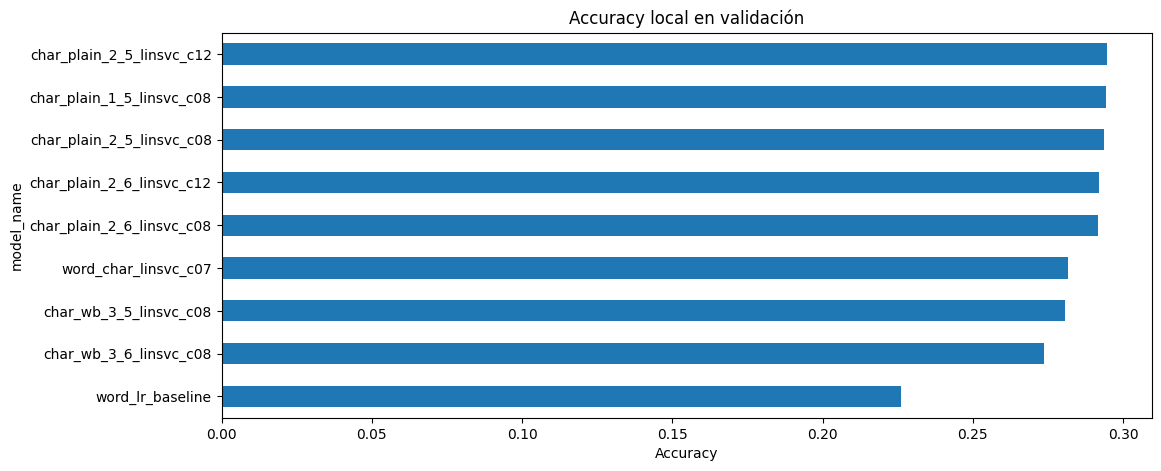

In [20]:
ax = (
    results_df.loc[results_df["status"] == "ok"]
    .sort_values("accuracy")
    .plot(
        kind="barh",
        x="model_name",
        y="accuracy",
        figsize=(12, 5),
        title="Accuracy local en validación",
        legend=False,
    )
)
ax.set_xlabel("Accuracy")
plt.show()


La idea ahora es elegir el mejor modelo individual y, además, mirar si un ensamble ponderado de los 3 mejores amerita una submission aparte.


## 9. Selección del mejor modelo

In [21]:
best_raw_row = successful_results_df.sort_values(
    ["accuracy", "macro_f1"], ascending=False
).iloc[0]
best_model_name = best_raw_row["model_name"]

selection_rows = [
    {
        "selection": "mejor_modelo_bruto",
        "model_name": best_model_name,
        "accuracy": best_raw_row["accuracy"],
        "macro_f1": best_raw_row["macro_f1"],
    }
]

if not ensemble_summary_df.empty:
    selection_rows.append(
        {
            "selection": "ensamble_top3_validacion",
            "model_name": "weighted_vote_top3",
            "accuracy": ensemble_summary_df.iloc[0]["accuracy"],
            "macro_f1": ensemble_summary_df.iloc[0]["macro_f1"],
        }
    )

selection_summary_df = pd.DataFrame(selection_rows)
display(selection_summary_df)


,selection,model_name,accuracy,macro_f1
0,mejor_modelo_bruto,char_plain_2_5_linsvc_c12,0.294698,0.287828
1,ensamble_top3_validacion,weighted_vote_top3,0.294061,0.286438


In [22]:
best_validation_predictions = validation_runs[best_model_name]["predictions"]
print(classification_report(y_valid, best_validation_predictions))


              precision    recall  f1-score   support

         150       0.78      0.84      0.81       157
         151       0.62      0.81      0.70       162
         152       0.66      0.67      0.66       157
         153       0.61      0.76      0.68       155
         154       0.52      0.62      0.57       166
         155       0.43      0.38      0.40       167
         156       0.33      0.42      0.37       158
         157       0.34      0.35      0.34       166
         158       0.28      0.34      0.31       156
         159       0.29      0.31      0.30       160
         160       0.16      0.13      0.14       170
         161       0.16      0.14      0.15       157
         162       0.22      0.20      0.21       162
         163       0.15      0.12      0.13       166
         164       0.21      0.19      0.20       161
         165       0.14      0.10      0.12       163
         166       0.11      0.08      0.09       156
         167       0.20    

## 10. Entrenamiento final del mejor modelo bruto

Este es el pipeline individual que se guarda como `.joblib`.


In [23]:
print(f"Entrenando modelo final: {best_model_name}")
train_start = time.time()

final_model = candidate_builders[best_model_name]()
final_model.fit(train_model_df["text_clean"], train_model_df["decade"])

training_elapsed = time.time() - train_start
print(f"Tiempo de entrenamiento final: {training_elapsed:.2f} segundos")
display(final_model)


Entrenando modelo final: char_plain_2_5_linsvc_c12
Tiempo de entrenamiento final: 97.71 segundos


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",False
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 11. Guardado del modelo

In [24]:
model_path = MODELS_DIR / f"{best_model_name}.joblib"
joblib.dump(final_model, model_path)
print(model_path)


C:\Users\userr\Proyecto-Machine_learning\models\char_plain_2_5_linsvc_c12.joblib


## 12. Predicción sobre `eval.csv`

In [25]:
prediction_start = time.time()
eval_predictions = final_model.predict(eval_model_df["text_clean"])
prediction_elapsed = time.time() - prediction_start

print(f"Tiempo de predicción sobre eval.csv: {prediction_elapsed:.2f} segundos")
pd.Series(eval_predictions).value_counts().sort_index().head()


Tiempo de predicción sobre eval.csv: 3.24 segundos


150     88
151    120
152     84
153    122
154    106
Name: count, dtype: int64

## 13. Generación del submission principal

Se genera el CSV base del mejor modelo individual.


In [26]:
submission_base_df = pd.DataFrame(
    {
        "id": eval_model_df["id"].astype(int),
        "answer": pd.Series(eval_predictions).astype(int),
    }
)

submission_base_path = SUBMISSIONS_DIR / "submission_best_model_raw.csv"
submission_base_df.to_csv(submission_base_path, index=False)

display(submission_base_df.head())
print(submission_base_path)


,id,answer
0,0,173
1,1,185
2,2,150
3,3,169
4,4,153


C:\Users\userr\Proyecto-Machine_learning\data\submissions\submission_best_model_raw.csv


## 14. Generación opcional de cinco envíos

Se generan:
1. mejor modelo individual,
2. segundo mejor modelo individual,
3. tercer mejor modelo individual,
4. cuarto mejor modelo individual,
5. ensamble ponderado de los 3 mejores.


In [27]:
if RUN_FIVE_SUBMISSIONS:
    ranked_models = successful_results_df.sort_values(
        ["accuracy", "macro_f1"], ascending=False
    )["model_name"].tolist()
    selected_for_submission = ranked_models[:TOP_MODELS_FOR_SUBMISSIONS]

    trained_models = {best_model_name: final_model}
    for model_name in selected_for_submission:
        if model_name not in trained_models:
            print(f"Entrenando {model_name} para submission pack...", flush=True)
            model = candidate_builders[model_name]()
            model.fit(train_model_df["text_clean"], train_model_df["decade"])
            trained_models[model_name] = model

    pack_rows = []
    eval_prediction_bank = {}

    upload_order = 1
    for model_name in selected_for_submission:
        model = trained_models[model_name]
        raw_predictions = model.predict(eval_model_df["text_clean"])
        eval_prediction_bank[model_name] = raw_predictions

        output_path = SUBMISSIONS_DIR / f"{upload_order:02d}_{model_name}_raw.csv"
        pd.DataFrame(
            {
                "id": eval_model_df["id"].astype(int),
                "answer": pd.Series(raw_predictions).astype(int),
            }
        ).to_csv(output_path, index=False)

        local_row = results_df.loc[results_df["model_name"] == model_name].iloc[0]
        pack_rows.append(
            {
                "upload_order": upload_order,
                "model_name": model_name,
                "variant": "raw",
                "estimated_local_accuracy": local_row["accuracy"],
                "estimated_local_macro_f1": local_row["macro_f1"],
                "submission_path": str(output_path.relative_to(PROJECT_ROOT)),
            }
        )
        upload_order += 1

    if INCLUDE_ENSEMBLE_SUBMISSION and len(selected_for_submission) >= 3:
        ensemble_members = selected_for_submission[:3]
        ensemble_prediction_map = {
            name: eval_prediction_bank[name] for name in ensemble_members
        }
        ensemble_weight_map = {
            name: float(
                results_df.loc[results_df["model_name"] == name, "accuracy"].iloc[0]
            )
            for name in ensemble_members
        }
        ensemble_predictions = weighted_vote_predictions(
            ensemble_prediction_map,
            ensemble_weight_map,
        )

        ensemble_output_path = SUBMISSIONS_DIR / "05_weighted_vote_top3.csv"
        pd.DataFrame(
            {
                "id": eval_model_df["id"].astype(int),
                "answer": pd.Series(ensemble_predictions).astype(int),
            }
        ).to_csv(ensemble_output_path, index=False)

        ensemble_local_accuracy = np.nan
        ensemble_local_macro_f1 = np.nan
        if not ensemble_summary_df.empty:
            ensemble_local_accuracy = ensemble_summary_df.iloc[0]["accuracy"]
            ensemble_local_macro_f1 = ensemble_summary_df.iloc[0]["macro_f1"]

        pack_rows.append(
            {
                "upload_order": 5,
                "model_name": "weighted_vote_top3",
                "variant": ", ".join(ensemble_members),
                "estimated_local_accuracy": ensemble_local_accuracy,
                "estimated_local_macro_f1": ensemble_local_macro_f1,
                "submission_path": str(ensemble_output_path.relative_to(PROJECT_ROOT)),
            }
        )

    submission_manifest_df = (
        pd.DataFrame(pack_rows)
        .sort_values("upload_order")
        .reset_index(drop=True)
    )
    manifest_path = SUBMISSIONS_DIR / "submission_manifest.csv"
    submission_manifest_df.to_csv(manifest_path, index=False)

    display(submission_manifest_df)
    print(manifest_path)
else:
    print("RUN_FIVE_SUBMISSIONS está en False. Solo se generó el submission principal.")


Entrenando char_plain_1_5_linsvc_c08 para submission pack...
Entrenando char_plain_2_5_linsvc_c08 para submission pack...
Entrenando char_plain_2_6_linsvc_c12 para submission pack...


,upload_order,model_name,variant,estimated_local_accuracy,estimated_local_macro_f1,submission_path
0,1,char_plain_2_5_linsvc_c12,raw,0.294698,0.287828,data\submissions\01_char_plain_2_5_linsvc_c12_...
1,2,char_plain_1_5_linsvc_c08,raw,0.294221,0.286468,data\submissions\02_char_plain_1_5_linsvc_c08_...
2,3,char_plain_2_5_linsvc_c08,raw,0.293743,0.285740,data\submissions\03_char_plain_2_5_linsvc_c08_...
3,4,char_plain_2_6_linsvc_c12,raw,0.291992,0.285298,data\submissions\04_char_plain_2_6_linsvc_c12_...


C:\Users\userr\Proyecto-Machine_learning\data\submissions\submission_manifest.csv


## 15. Conclusiones

1. Esta versión abre de verdad la búsqueda hacia **`analyzer="char"` puro**.
2. El `exact-match override` queda fuera porque ya no aportó.
3. El objetivo de esta corrida es salir con **4 modelos individuales distintos** y **1 ensamble**, listos para la siguiente ventana de submissions en Kaggle.
